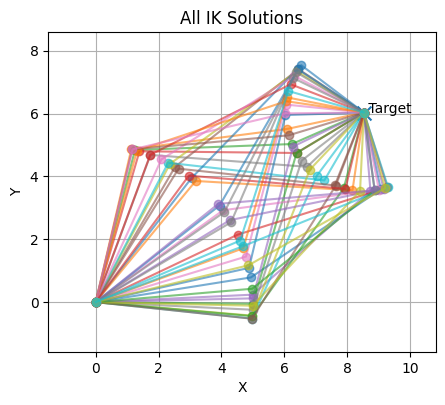

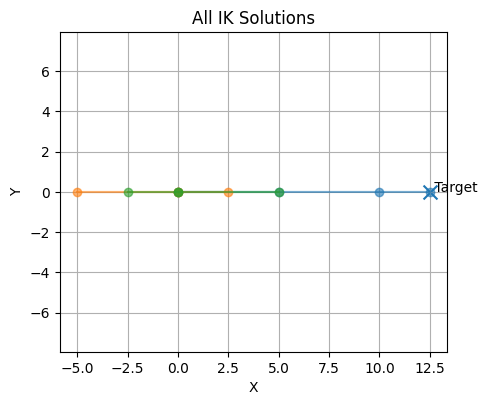

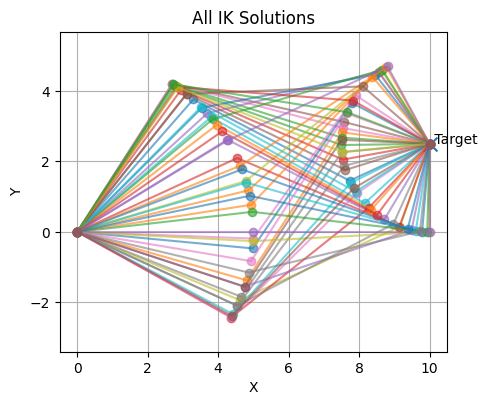

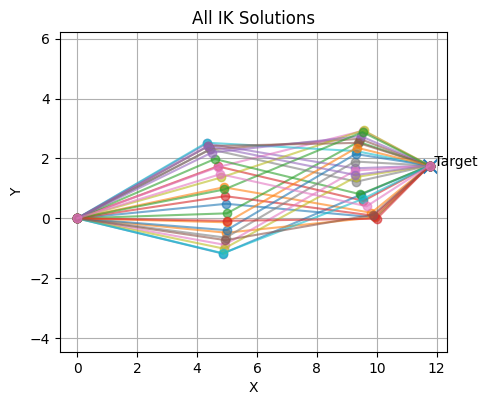

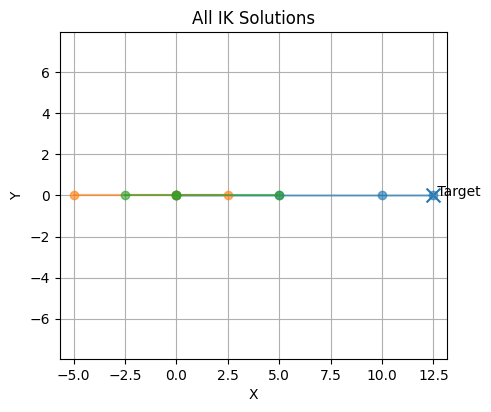

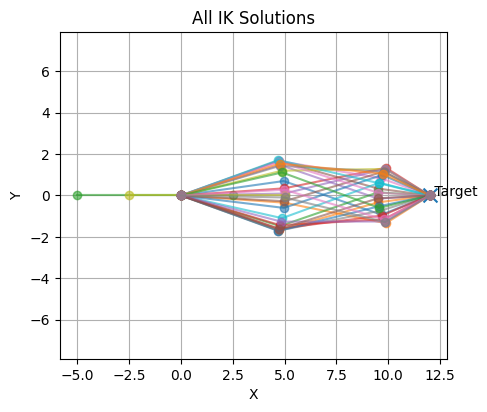

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import ttk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from scipy.optimize import least_squares

# -------- LINK LENGTHS --------
l1 = 5
l2 = 5
l3 = 2.5

# -------- FORWARD KINEMATICS FUNCTION --------
def fk(theta):
    t1, t2, t3 = theta
    x = l1*np.cos(t1) + l2*np.cos(t1+t2) + l3*np.cos(t1+t2+t3)
    y = l1*np.sin(t1) + l2*np.sin(t1+t2) + l3*np.sin(t1+t2+t3)
    return np.array([x, y])

# -------- NORMALIZE ANGLES --------
def normalize(theta):
    return (theta + np.pi) % (2*np.pi) - np.pi


# -------- COMPUTE FUNCTION --------
def compute():

    # Clear plot
    for widget in plot_frame.winfo_children():
        widget.destroy()

    # Clear text box
    output_text.delete(1.0, tk.END)

    xd = float(entry_x.get())
    yd = float(entry_y.get())

    def error(theta):
        return fk(theta) - np.array([xd, yd])

    solutions = []

    # -------- MULTIPLE INITIAL GUESSES --------
    for t1 in np.linspace(-np.pi, np.pi, 5):
        for t2 in np.linspace(-np.pi, np.pi, 5):
            for t3 in np.linspace(-np.pi, np.pi, 5):

                sol = least_squares(error, [t1, t2, t3])
                theta = normalize(sol.x)

                # Remove duplicates
                is_new = True
                for s in solutions:
                    if np.linalg.norm(theta - s) < 0.1:
                        is_new = False
                        break

                if is_new:
                    solutions.append(theta)

    # -------- PLOT --------
    fig, ax = plt.subplots(figsize=(5,5))

    output_text.insert(tk.END, f"Total Solutions: {len(solutions)}\n\n")

    for i, theta in enumerate(solutions):

        t1, t2, t3 = theta

        # Convert to degrees
        t1_deg = np.rad2deg(t1)
        t2_deg = np.rad2deg(t2)
        t3_deg = np.rad2deg(t3)

        # -------- PRINT IN GUI --------
        output_text.insert(tk.END,
            f"Solution {i+1}:\n"
            f"  θ1 = {t1_deg:.2f}°\n"
            f"  θ2 = {t2_deg:.2f}°\n"
            f"  θ3 = {t3_deg:.2f}°\n\n"
        )

        # -------- COMPUTE POSITIONS --------
        P0 = np.array([0, 0])

        P1 = np.array([
            l1*np.cos(t1),
            l1*np.sin(t1)
        ])

        P2 = P1 + np.array([
            l2*np.cos(t1+t2),
            l2*np.sin(t1+t2)
        ])

        P3 = P2 + np.array([
            l3*np.cos(t1+t2+t3),
            l3*np.sin(t1+t2+t3)
        ])

        x = [P0[0], P1[0], P2[0], P3[0]]
        y = [P0[1], P1[1], P2[1], P3[1]]

        ax.plot(x, y, '-o', alpha=0.6)

    # Target
    ax.scatter(xd, yd, marker='x', s=100)
    ax.text(xd, yd, ' Target')

    ax.set_title("All IK Solutions")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.axis('equal')
    ax.grid(True)

    canvas = FigureCanvasTkAgg(fig, master=plot_frame)
    canvas.draw()
    canvas.get_tk_widget().pack()


# -------- GUI --------
root = tk.Tk()
root.title("3-Link IK Solver (All Solutions)")
root.geometry("700x750")

ttk.Label(root, text="Desired X").pack()
entry_x = ttk.Entry(root)
entry_x.pack()

ttk.Label(root, text="Desired Y").pack()
entry_y = ttk.Entry(root)
entry_y.pack()

ttk.Button(root, text="Solve IK & Plot All", command=compute).pack(pady=10)

# -------- SCROLLABLE TEXT BOX --------
frame_text = ttk.Frame(root)
frame_text.pack(fill="both", expand=False)

scrollbar = ttk.Scrollbar(frame_text)
scrollbar.pack(side="right", fill="y")

output_text = tk.Text(frame_text, height=15, yscrollcommand=scrollbar.set)
output_text.pack(side="left", fill="both", expand=True)

scrollbar.config(command=output_text.yview)

# -------- PLOT FRAME --------
plot_frame = ttk.Frame(root)
plot_frame.pack(fill="both", expand=True)

root.mainloop()